# Model Evaluation

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas

import torch 
import numpy as np
import matplotlib.pyplot as plt
from object_handler import load_csv, load_pickle, load_h5

torch.set_num_threads(4)


## Line plot

In [2]:
def load_data(kpc_r :bool= False) -> tuple[np.ndarray]:
    """
    load data for plotting

    Params:
    - kpc_r: true if all r should be in kpc for the graph
    """
    post = load_pickle("./model_8/5d/samples.pkl")
    test_theta_raw = load_h5("./model_8/5d/test_theta.h5", "theta", "ndarray")[:, :8]
    _, index = np.unique(test_theta_raw, axis=0, return_index=True)
    index = np.sort(index)
    
    test_theta = test_theta_raw[index]

    raw_x = test_theta  
    raw_y = np.quantile(post, [0.025, 0.16, 0.5, 0.84, 0.975], axis=1)
    
    if kpc_r:
        raw_x[:, 5] = raw_x[:, 4] + raw_x[:, 5]
        raw_x[:, 6] = raw_x[:, 5] + raw_x[:, 6]
        raw_y[:, :, 5] = raw_y[:, :, 4] + raw_y[:, :, 5]
        raw_y[:, :, 6] = raw_y[:, :, 5] + raw_y[:, :, 6]
        
    return raw_x, raw_y
    
def prep_data(raw_x:np.ndarray, raw_y:np.ndarray, num_bins:int =20, kpc_r:bool = False) -> tuple[np.ndarray]:
    """
    Prepares data for graphing. Mostly binning data
    
    Params:
    - raw_x: the unprepared true data, raw_x.shape == (n, 8)
    - raw_y: unprepared simulated data, raw_y.shape = (5, n, 8)
    - num_bins: number of bins in the graph
    - kpc_r: true if all r should be in kpc for the graph
    
    """
    if not kpc_r:
        splits = np.linspace([0.5,  2,  -1,  3, -2, -3, -1, -0.5], 
                            [  3, 10,   2, 10,  2,  0,  3,    1], 
                            num_bins + 1)
    else:
        splits = np.linspace([0.5,  2,  -1,  3, -2, -5, -6, -0.5], 
                             [  3, 10,   2, 10,  2,  2,  5,    1], 
                            num_bins + 1)
    

    x = np.zeros((num_bins, 8))
    y = np.zeros((5, num_bins, 8))
    for c in range(8):
        bins = np.digitize(raw_x[:,c], splits[:,c]) - 1
        
        for i in range(num_bins):
            mask = (i == bins)
            x[i, c] = raw_x[mask][:,c].mean()
            
            for q, quantile in enumerate(raw_y):
                y[q, i, c] = quantile[mask][:,c].mean()
                
    return x.T, y.T

In [ ]:
def initialize_plot():
    """
    Initializes the plot
    """
    
    plt.rcParams["text.usetex"] = True
    
    fig = plt.figure(figsize=(15, 15), dpi=600, layout="constrained")
    
    # Divide the figure into a 3x3 grid of subfigures
    subfigs = fig.subfigures(3, 3, hspace=0.1, wspace=0.2)
    
    axs = []
    
    for i in range(3):
        for j in range(3):
            param_idx = i * 3 + j
            
            if param_idx == 8:
                # Keep the 9th slot empty and invisible
                subfigs[i, j].set_facecolor('none')
                continue
            
            # Create 2x1 subplots inside each independent subfigure block.
            # sharex=True here only shares x-axis within this specific block.
            ax_main, ax_res = subfigs[i, j].subplots(
                2, 1, 
                sharex=True, 
                gridspec_kw={'hspace': 0, 'height_ratios': [3, 1]}
            )
            
                
            axs.append((ax_main, ax_res))
    
    
    fig.suptitle("Truth v. Predicted DM profile parameters (Model 8, 3D)", y=1.02)

    handles, labels = axs[0][0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.98)

    )

    plt.tight_layout()
    # plt.show()
    
    return fig, axs

In [6]:
def plot_line(ax, x, y, truth_i, truth_f, x_name, y_name):
    """
    plot the line graph
    
    params:
    - ax: the axis to plot on
    - x: x values
    - y: y values, must be in quantiles, y.shape == (5,n)
    - truth: truth values to plot, truth.shape == (n,)
    - x_name: x-axis lable
    - y_name: y-axis lable
    """
    #2.5-97.5
    ax.fill_between(x, y[:,0], y[:,4], color=(133/255, 133/255, 247/255, 0.5), label="Mid 95%")

    #16-84
    ax.fill_between(x, y[:,1], y[:,3], color=(133/255, 133/255, 247/255, 0.8), label="Mid 68%")

    # Median
    ax.plot(x, y[:,2], color=(8/255, 2/255, 134/255), label="Median")

    # Truth
    ax.plot(truth_i, truth_f, color="red", linestyle = "--", label="Truth")
    
    ax.set_xlabel(x_name, fontsize=16)
    ax.set_ylabel(y_name, fontsize=16)
    
    ax.grid(True)
    ax.minorticks_on()
    
    # return ax

def plot_difference(ax, x, y, x_name, y_name):
    """
    plot the line graph for difference between simulated and truth
    
    params:
    - ax: the axis to plot on
    - x: x values
    - y: y values, must be in quantiles, y.shape == (5,n)
    """
    # ax = plot_line(ax, y - x, y, [0,0], x_name, y_name)
    x_repeated = np.tile(x, (5,1)).T
    plot_line(ax, x, y - x_repeated, [x.min(), x.max()], [0, 0], x_name, y_name)
    
    # return ax

In [17]:
def plot_figure(kpc_r:bool = False):
    raw_x, raw_y = load_data(kpc_r=kpc_r)
    x_data, y_data = prep_data(raw_x, raw_y, num_bins=25, kpc_r=kpc_r)
    
    if not kpc_r:
        x_name_list = [
        r"$\alpha$", 
        r"$\beta$", 
        r"$\gamma$",
        r"$\log_{10} (\rho _s)$",
        r"$\log_{10}(r_s)$", 
        r"$\log_{10}(r_* / r_s)$", 
        r"$\log_{10}(r_a / r_*)$", 
        r"$\beta_0$"
        ]
        
        y_bottom_name_list = [
        r"$\Delta \alpha$",
        r"$\Delta \beta$",
        r"$\Delta \gamma$",
        r"$\Delta \log_{10}(\rho_s)$",
        r"$\Delta \log_{10}(r_s)$",
        r"$\Delta \log_{10}(r_* / r_s)$",
        r"$\Delta \log_{10}(r_a / r_*)$",
        r"$\Delta \beta_0$"
    ]
        y_top_name_list = [
        r"$\hat{\alpha}$",
        r"$\hat{\beta}$",
        r"$\hat{\gamma}$",
        r"$\widehat{\log_{10}(\rho_s)}$",
        r"$\widehat{\log_{10}(r_s)}$",
        r"$\widehat{\log_{10}(r_* / r_s)}$",
        r"$\widehat{\log_{10}(r_a / r_*)}$",
        r"$\hat{\beta}_0$"
    ]
        
        low = [0.5,  2,  -1,  3, -2, -3, -1, -0.5]
        high = [  3, 10,   2, 10,  2,  0,  3,    1]
    else:
        x_name_list = [
                r"$\alpha$", 
                r"$\beta$", 
                r"$\gamma$",
                r"$\log_{10} (\rho _s)$",
                r"$\log_{10}(r_s)$", 
                r"$\log_{10}(r_*)$", 
                r"$\log_{10}(r_a)$", 
                r"$\beta_0$"
                ]
                
        y_bottom_name_list = [
        r"$\Delta \alpha$",
        r"$\Delta \beta$",
        r"$\Delta \gamma$",
        r"$\Delta \log_{10}(\rho_s)$",
        r"$\Delta \log_{10}(r_s)$",
        r"$\Delta \log_{10}(r_*)$",
        r"$\Delta \log_{10}(r_a)$",
        r"$\Delta \beta_0$"
    ]
        y_top_name_list = [
        r"$\hat{\alpha}$",
        r"$\hat{\beta}$",
        r"$\hat{\gamma}$",
        r"$\widehat{\log_{10}(\rho_s)}$",
        r"$\widehat{\log_{10}(r_s)}$",
        r"$\widehat{\log_{10}(r_*)}$",
        r"$\widehat{\log_{10}(r_a)}$",
        r"$\hat{\beta}_0$"
    ]
        low = [0.5,  2,  -1,  3, -2, -5, -6, -0.5]
        high = [ 3, 10,   2, 10,  2,  2,  5,    1]
        
    fig, axs = initialize_plot()

    for i, ax in enumerate(axs):
        # axs[i][0] = plot_line(ax[0], x_data[i], y_data[i], [low[i], high[i]], x_name_list[i], y_top_name_list[i])
        # axs[i][1] = plot_difference(ax[1], x_data[i], y_data[i], x_name_list[i], y_top_name_list[i])
        plot_line(ax[0], x_data[i], y_data[i], [low[i], high[i]], [low[i], high[i]], None, y_top_name_list[i])
        plot_difference(ax[1], x_data[i], y_data[i], x_name_list[i], y_bottom_name_list[i])
        
    # plt.tight_layout()
    plt.savefig("model_8/3d/model_evaluation_model_8_3d_transparent.png", transparent=True, bbox_inches="tight")
    
    plt.show()
        
    
    

In [18]:
plot_figure(kpc_r=True)

## Scatter plot

In [6]:
def load_data() -> tuple[np.ndarray]:
    """
    load data for plotting
    """
    post = load_pickle("./model_1/samples.pkl")
    
    test_theta_raw = load_csv("./model_1/test_theta.csv", "ndarray")
    _, index = np.unique(test_theta_raw, axis=0, return_index=True)
    index = np.sort(index)
    
    test_theta = test_theta_raw[index][:100]

    raw_x = test_theta  # shape: (100, 8)
    raw_y = np.quantile(post, [0.025, 0.16, 0.5, 0.84, 0.975], axis=1)  #shape: (5, 100, 8)
    
    return raw_x.T, raw_y.T

In [41]:
def plot_scatter(ax, x, y, truth, x_name, y_name):
    """
    Plot scatter plot
    
    params:
    - ax: the axis to plot on
    - x: x values
    - y: y values, must be in quantiles, y.shape == (5,n)
    - truth: truth values to plot, truth.shape == (n,)
    - x_name: x-axis lable
    - y_name: y-axis lable
    """
    
    plt_x = x
    plt_y = y[:,2]
    
    yerr_68 = np.array([
        plt_y - y[:,1],  # Distance down to the 16% quantile
        y[:,3] - plt_y   # Distance up to the 84% quantile
    ])

    yerr_95 = np.array([
        plt_y - y[:,0],  # Distance down to the 2.5% quantile
        y[:,4] - plt_y   # Distance up to the 97.5% quantile
    ])
    
    ax.scatter(plt_x, plt_y, 
               s=8, 
               c="green",
               zorder=3,
               label="Median")
    ax.errorbar(plt_x, plt_y, 
                yerr=yerr_68, 
                fmt='none', 
                ecolor=(78/255,78/255,222/255), 
                capsize=1, 
                elinewidth=0.5,
                label='Mid. 68\%',
                zorder=2)
    
    ax.errorbar(plt_x, plt_y, 
                yerr=yerr_95, 
                fmt='none', 
                ecolor=(180/255,180/255,237/255), 
                capsize=1, 
                elinewidth=0.5,
                label='Mid. 95\%',
                zorder=1)
    
        # Truth

    ax.plot(truth, truth, color="red", linestyle = "--", label="Truth")
    
    ax.set_ylabel(y_name)
    ax.set_xlabel(x_name)
    
    return ax

In [ ]:
def initialize_plot():
    plt.rcParams["text.usetex"] = True
    fig, axs = plt.subplots(3, 3, figsize=(14,14))
    
    
    return fig, axs

In [50]:
def plot_figure():
    x_data, y_data = load_data()
    
    x_name_list = [
    r"$\alpha$", 
    r"$\beta$", 
    r"$\gamma$",
    r"$\log_{10} (\rho _s)$",
    r"$\log_{10}(r_s)$", 
    r"$\log_{10}(r_* / r_s)$", 
    r"$\log_{10}(r_a / r_*)$", 
    r"$\beta_0$"
    ]
    
    y_top_name_list = [
    r"$\hat{\alpha}$",
    r"$\hat{\beta}$",
    r"$\hat{\gamma}$",
    r"$\hat{\log_{10}(\rho_s)}$",
    r"$\hat{\log_{10}(r_s)}$",
    r"$\hat{\log_{10}(r_* / r_s)}$",
    r"$\hat{\log_{10}(r_a / r_*)}$",
    r"$\hat{\beta}_0$"
]
    
    low = [0.5,  2,  -1,  3, -2, -3, -1, -0.5]
    high = [  3, 10,   2, 10,  2,  0,  3,    1]
        
        
    # plot
    fig, axs = initialize_plot()
    for index in range(8):
        i = index // 3
        j = index % 3
        axs[i,j] = plot_scatter(axs[i,j], x_data[index], y_data[index], [low[index], high[index]], x_name_list[index], y_top_name_list[index])

    axs[2, 2].set_axis_off()

    # title
    fig.suptitle("Truth v. Predicted DM profile parameters (Model 1)", y=1.02)
    handles, labels = axs[0,0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.0)

    )
    plt.tight_layout()

    plt.show()
    

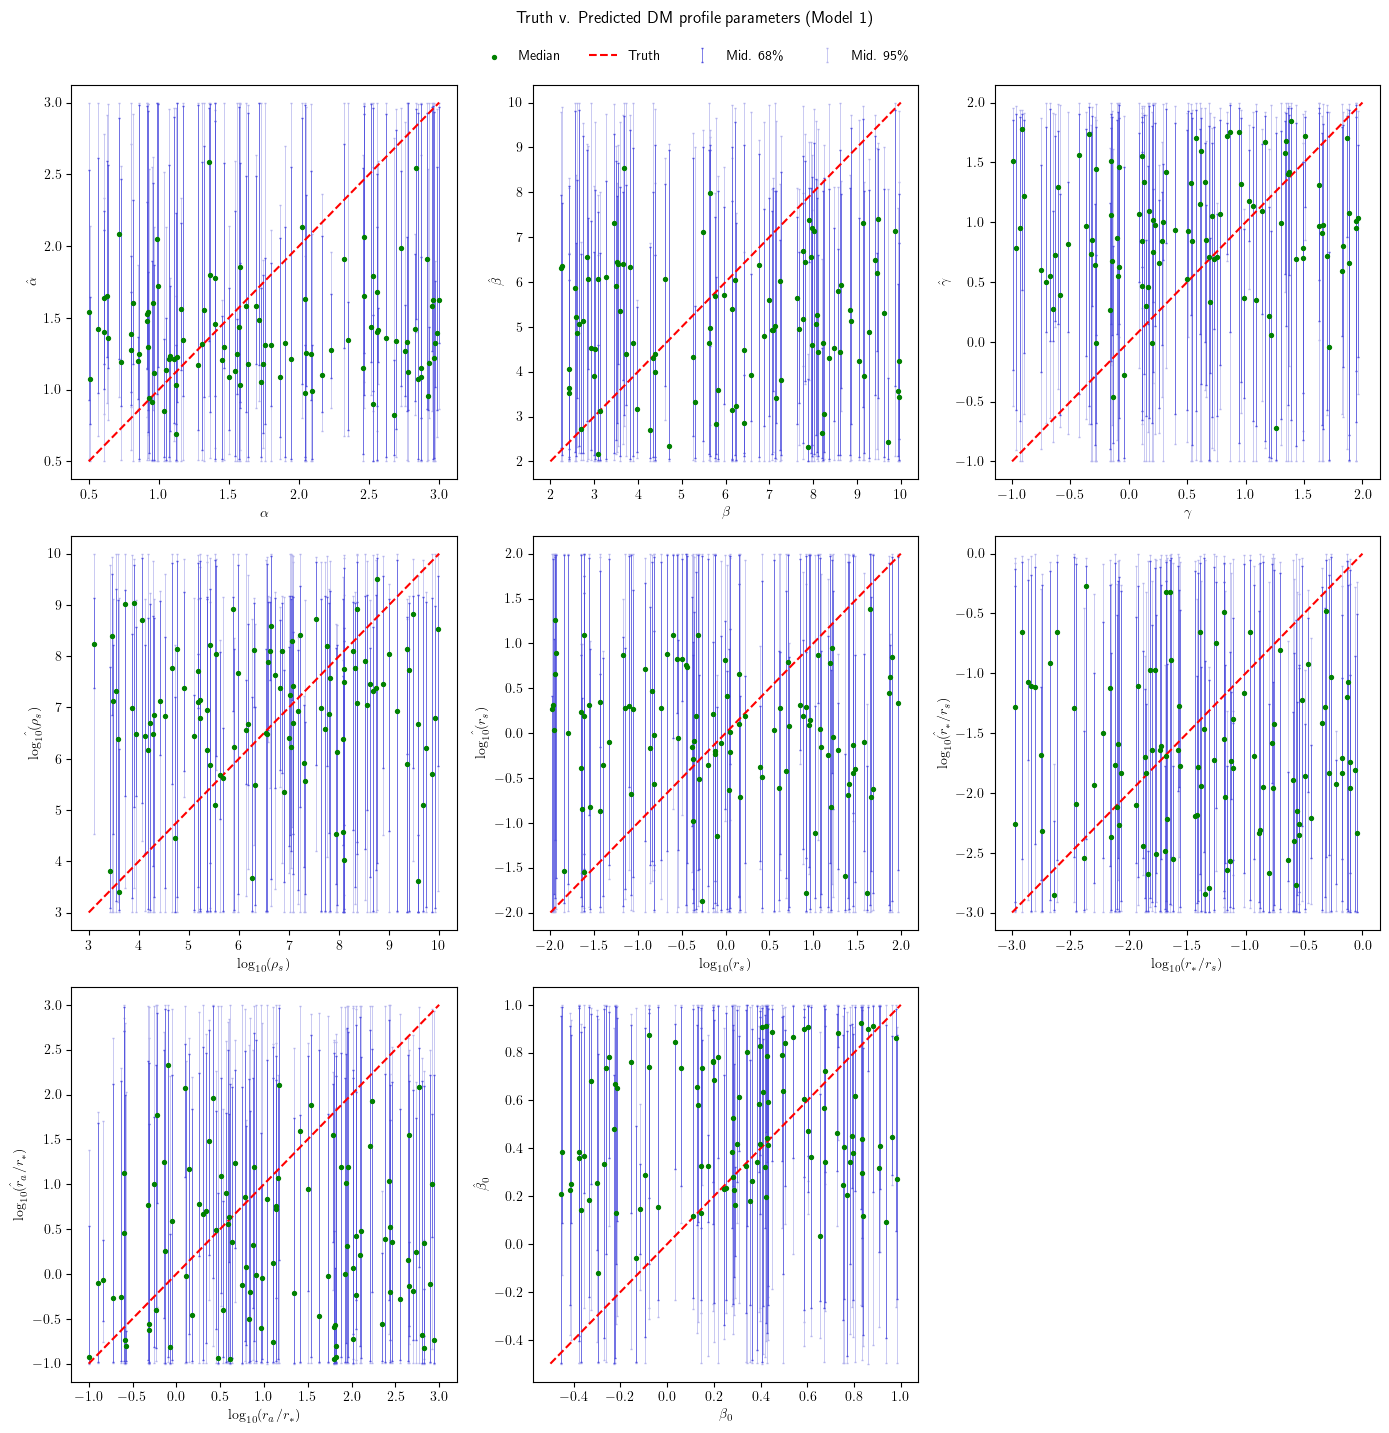

In [51]:
plot_figure()